In [1]:

import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Load the primary dataset
with open('dirichlet_polynomials_N10000_T10000-20000.pkl', 'rb') as f:
 dirichlet_data = pickle.load(f)

# Examine the structure
print("Keys in dataset:", dirichlet_data.keys())
print("\nMetadata:")
for key, value in dirichlet_data['metadata'].items():
 print(f" {key}: {value}")
 
print("\nFunction classes available:")
for func in dirichlet_data['data'].keys():
 print(f" {func}")


Keys in dataset: dict_keys(['metadata', 'data'])

Metadata:
 description: Dirichlet polynomial evaluations for ω-class geometry research
 T_min: 10000
 T_max: 20000
 num_points: 2000
 N: 10000
 function_classes: ['zeta', 'L_DH', 'liouville', 'f_rand', 'f_fully_rand']
 generation_date: 2024
 seed: 42

Function classes available:
 zeta
 L_DH
 liouville
 f_rand
 f_fully_rand


In [2]:

# Extract L_DH data and examine
L_DH_data = dirichlet_data['data']['L_DH']
print("L_DH data keys:", L_DH_data.keys())
print("\nt_values shape:", L_DH_data['t_values'].shape)
print("modulus shape:", L_DH_data['modulus'].shape)
print("\nFirst 5 t values:", L_DH_data['t_values'][:5])
print("First 5 modulus values:", L_DH_data['modulus'][:5])
print("\nModulus statistics:")
print(f" Mean: {np.mean(L_DH_data['modulus']):.4f}")
print(f" Std: {np.std(L_DH_data['modulus']):.4f}")
print(f" Max: {np.max(L_DH_data['modulus']):.4f}")
print(f" Min: {np.min(L_DH_data['modulus']):.4f}")


L_DH data keys: dict_keys(['t_values', 'D_F', 'modulus', 'argument', 'N'])

t_values shape: (2000,)
modulus shape: (2000,)

First 5 t values: [10000. 10005.00250125 10010.0050025 10015.00750375
 10020.010005 ]
First 5 modulus values: [0.46427134 5.78090128 2.58297097 4.33498898 1.89125395]

Modulus statistics:
 Mean: 1.6818
 Std: 1.3618
 Max: 9.9854
 Min: 0.0066


In [3]:

# Select 10 diverse t values for parameter search
# Strategy: select values spanning the range with variety in modulus values
t_values_full = L_DH_data['t_values']
modulus_full = L_DH_data['modulus']

# Select indices: spread across the range, with different modulus values
# Use quartiles and different regions
indices = [
 0, # Start
 250, # First quarter
 500, # Mid-first half
 750, # Around middle
 1000, # Middle
 1250, # After middle
 1500, # Third quarter
 1750, # Near end
 1999, # End
 # Add one more - pick a peak
 np.argmax(modulus_full) # Maximum modulus location
]

target_t_values = t_values_full[indices]
target_modulus = modulus_full[indices]

print("Selected 10 target t values and their modulus:")
for i, (t, mod) in enumerate(zip(target_t_values, target_modulus)):
 print(f" {i}: t={t:.2f}, |D_F|={mod:.6f}")


Selected 10 target t values and their modulus:
 0: t=10000.00, |D_F|=0.464271
 1: t=11250.63, |D_F|=2.476742
 2: t=12501.25, |D_F|=0.575800
 3: t=13751.88, |D_F|=1.631040
 4: t=15002.50, |D_F|=0.686666
 5: t=16253.13, |D_F|=1.701287
 6: t=17503.75, |D_F|=1.321289
 7: t=18754.38, |D_F|=0.772596
 8: t=20000.00, |D_F|=0.877942
 9: t=13381.69, |D_F|=9.985393


In [4]:

# Implement pre-computation of arithmetic functions needed
def precompute_primes(max_n):
 """Sieve of Eratosthenes to find all primes up to max_n"""
 sieve = np.ones(max_n + 1, dtype=bool)
 sieve[0:2] = False
 for i in range(2, int(np.sqrt(max_n)) + 1):
 if sieve[i]:
 sieve[i*i::i] = False
 return np.where(sieve)[0]

def precompute_omega(max_n):
 """Compute ω(n) = number of distinct prime factors for n ≤ max_n"""
 omega = np.zeros(max_n + 1, dtype=int)
 for p in range(2, max_n + 1):
 if omega[p] == 0: # p is prime
 for multiple in range(p, max_n + 1, p):
 omega[multiple] += 1
 return omega

# Pre-compute for N=10000
N = 10000
print("Pre-computing primes and ω(n) for n ≤ 10000...")
primes = precompute_primes(N)
omega = precompute_omega(N)
print(f"Found {len(primes)} primes")
print(f"ω(100) = {omega[100]} (should be 2, since 100 = 2² × 5²)")
print(f"ω(30) = {omega[30]} (should be 3, since 30 = 2 × 3 × 5)")


Pre-computing primes and ω(n) for n ≤ 10000...
Found 1229 primes
ω(100) = 2 (should be 2, since 100 = 2² × 5²)
ω(30) = 3 (should be 3, since 30 = 2 × 3 × 5)


In [5]:

# Implement Dirichlet character functions
def primitive_characters_mod_q(q):
 """
 Generate all primitive Dirichlet characters mod q.
 Returns list of tuples (q, character_values_dict)
 where character_values_dict maps n -> χ(n) for gcd(n,q)=1
 """
 from math import gcd
 
 # For small moduli, we can enumerate explicitly
 # A primitive character mod q has conductor q
 
 characters = []
 
 if q == 3:
 # χ(n) = (n/3) Legendre symbol, non-principal
 char = {1: 1, 2: -1}
 characters.append((3, char))
 
 elif q == 4:
 # χ(n) = (-1)^((n-1)/2)
 char = {1: 1, 3: -1}
 characters.append((4, char))
 
 elif q == 5:
 # Two primitive characters mod 5
 # χ₁: 1, i, -i, -1 (order 4)
 # χ₂: 1, -i, i, -1 (conjugate)
 char1 = {1: 1, 2: 1j, 3: -1j, 4: -1}
 char2 = {1: 1, 2: -1j, 3: 1j, 4: -1}
 characters.append((5, char1))
 characters.append((5, char2))
 
 elif q == 7:
 # Primitive characters mod 7
 # These have order 6 or 3
 # For simplicity, use quadratic character
 # Legendre symbol (n/7)
 char = {1: 1, 2: 1, 3: -1, 4: 1, 5: -1, 6: -1}
 characters.append((7, char))
 
 elif q == 8:
 # χ(n) = (-1)^((n²-1)/8) for odd n
 char = {1: 1, 3: -1, 5: -1, 7: 1}
 characters.append((8, char))
 
 elif q == 10:
 # Primitive character mod 10
 # χ(n) = χ₅(n) where χ₅ is from mod 5
 char = {1: 1, 3: 1j, 7: -1j, 9: -1}
 characters.append((10, char))
 
 elif q == 12:
 # Primitive characters mod 12
 char = {1: 1, 5: -1, 7: -1, 11: 1}
 characters.append((12, char))
 
 return characters

# Test character generation
print("Primitive characters:")
for q in [5, 7, 8, 10, 12]:
 chars = primitive_characters_mod_q(q)
 print(f" mod {q}: {len(chars)} character(s)")


Primitive characters:
 mod 5: 2 character(s)
 mod 7: 1 character(s)
 mod 8: 1 character(s)
 mod 10: 1 character(s)
 mod 12: 1 character(s)


In [6]:

def evaluate_character(n, q, char_dict):
 """
 Evaluate Dirichlet character χ(n) where χ has modulus q.
 Returns 0 if gcd(n,q) > 1, otherwise returns char_dict[n mod q]
 """
 from math import gcd
 if gcd(n, q) > 1:
 return 0
 return char_dict[n % q]

def kahan_sum(terms):
 """Kahan compensated summation for improved numerical accuracy"""
 sum_val = 0.0
 c = 0.0 # Compensation for lost low-order bits
 for term in terms:
 y = term - c
 t = sum_val + y
 c = (t - sum_val) - y
 sum_val = t
 return sum_val

def compute_L_DH(t, N, q, char_dict, kappa):
 """
 Compute Davenport-Heilbronn L-function
 L_DH(1/2 + it) = Σ_{n=1}^N χ(n) * (ω(n) + κ) / n^(1/2 + it)
 
 Parameters:
 - t: imaginary part of s
 - N: truncation
 - q: character modulus
 - char_dict: dictionary mapping n -> χ(n) for coprime n
 - kappa: constant offset
 
 Returns: complex value D_F(t; N)
 """
 # We'll use Kahan summation on real and imaginary parts separately
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 chi_n = evaluate_character(n, q, char_dict)
 if chi_n == 0:
 continue
 
 omega_n = omega[n]
 coefficient = chi_n * (omega_n + kappa)
 
 # n^(1/2 + it) = n^(1/2) * n^(it) = sqrt(n) * e^(it*log(n))
 # So 1/n^(1/2 + it) = 1/sqrt(n) * e^(-it*log(n))
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 
 # coefficient * e^(i*phase) / sqrt(n)
 factor = coefficient / sqrt_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 # Handle complex coefficient
 if isinstance(factor, complex):
 real_part = (factor.real * cos_phase - factor.imag * sin_phase)
 imag_part = (factor.real * sin_phase + factor.imag * cos_phase)
 else:
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

# Test with a simple case
test_q = 5
test_chars = primitive_characters_mod_q(test_q)
test_char = test_chars[0][1]
test_kappa = 0.0
test_t = 10000.0

result = compute_L_DH(test_t, N, test_q, test_char, test_kappa)
print(f"Test L_DH computation at t={test_t}:")
print(f" Result: {result}")
print(f" Modulus: {abs(result):.6f}")


Test L_DH computation at t=10000.0:
 Result: (1.6618078309067557+3.1750077072648666j)
 Modulus: 3.583613


In [7]:

# Now implement the parameter search
# We'll search over:
# - Characters mod 5, 7, 8, 10, 12
# - κ values in [-1, 1] with fine grid

def compute_mse(t_targets, modulus_targets, q, char_dict, kappa):
 """Compute MSE between target modulus and computed L_DH modulus"""
 computed_moduli = []
 for t in t_targets:
 result = compute_L_DH(t, N, q, char_dict, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - modulus_targets) ** 2)
 return mse

# Prepare parameter grid
moduli = [5, 7, 8, 10, 12]
kappa_values = np.linspace(-1, 1, 21) # Start with coarse grid

print("Starting parameter search...")
print(f"Testing {sum([len(primitive_characters_mod_q(q)) for q in moduli])} characters")
print(f"Testing {len(kappa_values)} κ values: {kappa_values}")
print(f"Total combinations: {sum([len(primitive_characters_mod_q(q)) for q in moduli]) * len(kappa_values)}")
print()

results = []

for q in moduli:
 chars = primitive_characters_mod_q(q)
 for char_idx, (_, char_dict) in enumerate(chars):
 print(f"Testing mod {q}, character {char_idx+1}/{len(chars)}...")
 
 for kappa in kappa_values:
 mse = compute_mse(target_t_values, target_modulus, q, char_dict, kappa)
 results.append({
 'q': q,
 'char_idx': char_idx,
 'char_dict': char_dict,
 'kappa': kappa,
 'mse': mse
 })

# Sort by MSE
results.sort(key=lambda x: x['mse'])

# Show top 10 results
print("\nTop 10 parameter combinations by MSE:")
for i, r in enumerate(results[:10]):
 print(f"{i+1}. mod {r['q']}, char {r['char_idx']}, κ={r['kappa']:.3f}: MSE={r['mse']:.6f}")


Starting parameter search...
Testing 6 characters
Testing 21 κ values: [-1. -0.9 -0.8 -0.7 -0.6 -0.5 -0.4 -0.3 -0.2 -0.1 0. 0.1 0.2 0.3
 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Total combinations: 126

Testing mod 5, character 1/2...


Testing mod 5, character 2/2...


Testing mod 7, character 1/1...


Testing mod 8, character 1/1...


Testing mod 10, character 1/1...


Testing mod 12, character 1/1...



Top 10 parameter combinations by MSE:
1. mod 10, char 0, κ=-1.000: MSE=7.213642
2. mod 10, char 0, κ=-0.900: MSE=7.268674
3. mod 10, char 0, κ=-0.800: MSE=7.349915
4. mod 10, char 0, κ=-0.700: MSE=7.455447
5. mod 10, char 0, κ=-0.600: MSE=7.585168
6. mod 10, char 0, κ=-0.500: MSE=7.742188
7. mod 10, char 0, κ=-0.400: MSE=7.931152
8. mod 8, char 0, κ=-1.000: MSE=8.013930
9. mod 10, char 0, κ=-0.300: MSE=8.156348
10. mod 8, char 0, κ=-0.900: MSE=8.402537


In [8]:

# The best fit is mod 10, κ=-1. Let's refine the search around this region
# Try κ values very close to -1

best_q = 10
best_char_dict = primitive_characters_mod_q(10)[0][1]

# Fine-grained search around κ = -1
kappa_fine = np.linspace(-1.2, -0.8, 41)

print("Refining search around mod 10, κ=-1...")
refined_results = []

for kappa in kappa_fine:
 mse = compute_mse(target_t_values, target_modulus, best_q, best_char_dict, kappa)
 refined_results.append({
 'kappa': kappa,
 'mse': mse
 })

refined_results.sort(key=lambda x: x['mse'])

print("\nTop 10 refined κ values:")
for i, r in enumerate(refined_results[:10]):
 print(f"{i+1}. κ={r['kappa']:.4f}: MSE={r['mse']:.6f}")

best_kappa = refined_results[0]['kappa']
best_mse = refined_results[0]['mse']

print(f"\nBest parameters found:")
print(f" Modulus q: {best_q}")
print(f" κ: {best_kappa:.6f}")
print(f" MSE: {best_mse:.6f}")


Refining search around mod 10, κ=-1...



Top 10 refined κ values:
1. κ=-1.1400: MSE=7.184465
2. κ=-1.1300: MSE=7.184602
3. κ=-1.1500: MSE=7.184637
4. κ=-1.1200: MSE=7.185047
5. κ=-1.1600: MSE=7.185119
6. κ=-1.1100: MSE=7.185797
7. κ=-1.1700: MSE=7.185914
8. κ=-1.1000: MSE=7.186849
9. κ=-1.1800: MSE=7.187025
10. κ=-1.0900: MSE=7.188204

Best parameters found:
 Modulus q: 10
 κ: -1.140000
 MSE: 7.184465


In [9]:

# Even finer search around κ = -1.14
kappa_ultra_fine = np.linspace(-1.16, -1.12, 41)

print("Ultra-fine search around κ=-1.14...")
ultra_refined_results = []

for kappa in kappa_ultra_fine:
 mse = compute_mse(target_t_values, target_modulus, best_q, best_char_dict, kappa)
 ultra_refined_results.append({
 'kappa': kappa,
 'mse': mse
 })

ultra_refined_results.sort(key=lambda x: x['mse'])

print("\nTop 5 ultra-refined κ values:")
for i, r in enumerate(ultra_refined_results[:5]):
 print(f"{i+1}. κ={r['kappa']:.6f}: MSE={r['mse']:.8f}")

best_kappa = ultra_refined_results[0]['kappa']
best_mse = ultra_refined_results[0]['mse']

print(f"\nFinal best parameters:")
print(f" Modulus q: {best_q}")
print(f" κ: {best_kappa:.8f}")
print(f" MSE: {best_mse:.8f}")


Ultra-fine search around κ=-1.14...



Top 5 ultra-refined κ values:
1. κ=-1.139000: MSE=7.18446480
2. κ=-1.140000: MSE=7.18446493
3. κ=-1.138000: MSE=7.18446776
4. κ=-1.141000: MSE=7.18446815
5. κ=-1.137000: MSE=7.18447380

Final best parameters:
 Modulus q: 10
 κ: -1.13900000
 MSE: 7.18446480


In [10]:

# Verify the fit quality by comparing computed vs actual modulus
print("Verification of fit quality at the 10 target points:")
print(f"Using: mod {best_q}, κ={best_kappa:.6f}\n")

computed_values = []
for i, t in enumerate(target_t_values):
 result = compute_L_DH(t, N, best_q, best_char_dict, best_kappa)
 computed_mod = abs(result)
 computed_values.append(computed_mod)
 actual_mod = target_modulus[i]
 error = computed_mod - actual_mod
 rel_error = error / actual_mod * 100 if actual_mod > 0 else 0
 
 print(f"t={t:8.2f}: Computed={computed_mod:.6f}, Actual={actual_mod:.6f}, "
 f"Error={error:+.6f} ({rel_error:+.2f}%)")

computed_values = np.array(computed_values)
mse = np.mean((computed_values - target_modulus) ** 2)
mae = np.mean(np.abs(computed_values - target_modulus))
print(f"\nMSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")


Verification of fit quality at the 10 target points:
Using: mod 10, κ=-1.139000

t=10000.00: Computed=2.377534, Actual=0.464271, Error=+1.913263 (+412.10%)
t=11250.63: Computed=2.539356, Actual=2.476742, Error=+0.062614 (+2.53%)
t=12501.25: Computed=0.864034, Actual=0.575800, Error=+0.288234 (+50.06%)
t=13751.88: Computed=1.546965, Actual=1.631040, Error=-0.084075 (-5.15%)
t=15002.50: Computed=1.279933, Actual=0.686666, Error=+0.593267 (+86.40%)
t=16253.13: Computed=2.411299, Actual=1.701287, Error=+0.710012 (+41.73%)
t=17503.75: Computed=2.964322, Actual=1.321289, Error=+1.643033 (+124.35%)
t=18754.38: Computed=0.703951, Actual=0.772596, Error=-0.068645 (-8.88%)
t=20000.00: Computed=0.702713, Actual=0.877942, Error=-0.175229 (-19.96%)


t=13381.69: Computed=1.954269, Actual=9.985393, Error=-8.031124 (-80.43%)

MSE: 7.184465
MAE: 1.356950


In [11]:

# The MSE is still quite high. Let me check if the issue is that we need to try 
# other character representations or interpretations.
# Let me look at all the modulus values across the full range to see the scale of differences

print("Computing L_DH for all 2000 t values with best parameters...")
print(f"Parameters: mod {best_q}, κ={best_kappa:.6f}\n")

all_computed_moduli = []
for t in t_values_full:
 result = compute_L_DH(t, N, best_q, best_char_dict, best_kappa)
 all_computed_moduli.append(abs(result))

all_computed_moduli = np.array(all_computed_moduli)

# Compare statistics
print("Statistics comparison:")
print(f" Computed | Actual")
print(f"Mean: {np.mean(all_computed_moduli):8.4f} | {np.mean(modulus_full):8.4f}")
print(f"Std: {np.std(all_computed_moduli):8.4f} | {np.std(modulus_full):8.4f}")
print(f"Max: {np.max(all_computed_moduli):8.4f} | {np.max(modulus_full):8.4f}")
print(f"Min: {np.min(all_computed_moduli):8.4f} | {np.min(modulus_full):8.4f}")

# Full MSE
full_mse = np.mean((all_computed_moduli - modulus_full) ** 2)
full_mae = np.mean(np.abs(all_computed_moduli - modulus_full))
correlation = np.corrcoef(all_computed_moduli, modulus_full)[0, 1]

print(f"\nFull dataset metrics:")
print(f"MSE: {full_mse:.6f}")
print(f"MAE: {full_mae:.6f}")
print(f"Correlation: {correlation:.6f}")


Computing L_DH for all 2000 t values with best parameters...
Parameters: mod 10, κ=-1.139000



Statistics comparison:
 Computed | Actual
Mean: 1.4769 | 1.6818
Std: 0.8652 | 1.3618
Max: 8.7547 | 9.9854
Min: 0.0540 | 0.0066

Full dataset metrics:
MSE: 2.319593
MAE: 1.037980
Correlation: 0.138137


In [12]:

# The correlation is very low (0.14), suggesting this might not be the right parameters
# Let me explore if maybe the character definition is different
# Let me try the principal character (trivial character) and also try without the χ(n) factor

# Maybe the L_DH is defined differently? Let's try:
# 1. Without character (set χ(n) = 1)
# 2. With different character definitions

def compute_L_DH_no_char(t, N, kappa):
 """
 Compute L-function without character: Σ_{n=1}^N (ω(n) + κ) / n^(1/2 + it)
 """
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 omega_n = omega[n]
 coefficient = omega_n + kappa
 
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 
 factor = coefficient / sqrt_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

# Search over κ without character
print("Searching for κ without character multiplication...")
kappa_range = np.linspace(-3, 3, 61)

no_char_results = []
for kappa in kappa_range:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_DH_no_char(t, N, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 no_char_results.append({
 'kappa': kappa,
 'mse': mse
 })

no_char_results.sort(key=lambda x: x['mse'])

print("\nTop 10 κ values (no character):")
for i, r in enumerate(no_char_results[:10]):
 print(f"{i+1}. κ={r['kappa']:.4f}: MSE={r['mse']:.6f}")


Searching for κ without character multiplication...



Top 10 κ values (no character):
1. κ=-1.6000: MSE=9.753819
2. κ=-1.7000: MSE=9.783935
3. κ=-1.5000: MSE=9.813182
4. κ=-1.8000: MSE=9.865729
5. κ=-1.4000: MSE=9.985096
6. κ=-1.9000: MSE=10.063479
7. κ=-1.3000: MSE=10.263242
8. κ=-2.0000: MSE=10.405017
9. κ=-1.2000: MSE=10.636674
10. κ=-2.1000: MSE=10.897698


In [13]:

# This is worse. Let me reconsider - maybe I need to look at the complex values directly
# rather than just modulus. Let me check the D_F complex values in the dataset

L_DH_D_F = dirichlet_data['data']['L_DH']['D_F']
print("L_DH D_F (complex values):")
print(f"Shape: {L_DH_D_F.shape}")
print(f"Type: {L_DH_D_F.dtype}")
print("\nFirst 5 complex values:")
for i in range(5):
 print(f" t={t_values_full[i]:.2f}: D_F = {L_DH_D_F[i]}, |D_F| = {abs(L_DH_D_F[i]):.6f}")

# Maybe I should match complex values, not just modulus?
# But also, let me think about this differently - maybe the character is defined differently
# Let me try the Legendre symbol characters more carefully


L_DH D_F (complex values):
Shape: (2000,)
Type: complex128

First 5 complex values:
 t=10000.00: D_F = (0.30221584872833535+0.35243929922282297j), |D_F| = 0.464271
 t=10005.00: D_F = (5.276259667567592+2.3621819485062554j), |D_F| = 5.780901
 t=10010.01: D_F = (2.5794118899350944-0.13554820978569052j), |D_F| = 2.582971
 t=10015.01: D_F = (3.7204149262508706-2.2250038765999434j), |D_F| = 4.334989
 t=10020.01: D_F = (0.9868352075226013-1.6133808478591485j), |D_F| = 1.891254


In [14]:

# Let me think about this problem from a different angle
# The documentation mentions Davenport-Heilbronn but doesn't specify the exact form
# Let me look at what function classes are mentioned in the dataset description

# From the description: F4 is L_DH
# Let me check if there are references to the mathematical form

# Actually, wait - let me reconsider the character mod 10
# A character mod 10 factors as characters mod 2 and mod 5
# The primitive character mod 10 I defined might not be correct

# Let me recalculate the primitive character mod 10 more carefully
# A primitive character mod 10 must be non-trivial on both 2 and 5

def get_primitive_char_mod_10():
 """
 The primitive character mod 10 is induced from the character mod 5
 For n coprime to 10, χ(n) depends on n mod 5
 """
 # This is χ₅ extended to mod 10
 # χ(n) = 0 if gcd(n, 10) > 1
 # For coprime n, χ(n) = χ₅(n mod 5)
 
 # Quartic character mod 5
 char = {
 1: 1,
 3: 1j, # Actually this depends on which root of unity
 7: -1j, # 7 ≡ 2 (mod 5)
 9: -1 # 9 ≡ 4 (mod 5)
 }
 return char

# Actually, let me reconsider all primitive characters more systematically
# using the Legendre/Kronecker symbols

def legendre_symbol(a, p):
 """Compute Legendre symbol (a/p) for odd prime p"""
 if a % p == 0:
 return 0
 
 # Use Euler's criterion: (a/p) ≡ a^((p-1)/2) (mod p)
 result = pow(a, (p - 1) // 2, p)
 return -1 if result == p - 1 else result

# Test mod 5 characters using Legendre symbol
print("Testing mod 5 character using Legendre symbol:")
for n in range(1, 10):
 if n % 5 != 0:
 leg = legendre_symbol(n, 5)
 print(f" ({n}/5) = {leg:2d}")


Testing mod 5 character using Legendre symbol:
 (1/5) = 1
 (2/5) = -1
 (3/5) = -1
 (4/5) = 1
 (6/5) = 1
 (7/5) = -1
 (8/5) = -1
 (9/5) = 1


In [15]:

# So the quadratic character mod 5 is {1:1, 2:-1, 3:-1, 4:1}
# This is different from the quartic characters I tried before
# Let me test all possible real characters (Kronecker symbols)

def real_char_mod_5():
 """Real (quadratic) character mod 5"""
 return {1: 1, 2: -1, 3: -1, 4: 1}

def real_char_mod_8():
 """Real character mod 8: χ(n) = (-1)^((n²-1)/8)"""
 # For n odd: 1→1, 3→-1, 5→-1, 7→1
 return {1: 1, 3: -1, 5: -1, 7: 1}

def real_char_mod_12():
 """Real character mod 12"""
 # This is (n/3) Legendre symbol
 # For n coprime to 12: based on n mod 3
 return {1: 1, 5: -1, 7: 1, 11: -1}

# Let me test with real characters only
print("Testing with real (quadratic) characters...")

real_chars = [
 (5, real_char_mod_5(), "quadratic mod 5"),
 (8, real_char_mod_8(), "quadratic mod 8"),
 (12, real_char_mod_12(), "quadratic mod 12")
]

kappa_range = np.linspace(-2, 1, 31)

real_char_results = []

for q, char_dict, name in real_chars:
 print(f"\nTesting {name}...")
 for kappa in kappa_range:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_DH(t, N, q, char_dict, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 real_char_results.append({
 'q': q,
 'name': name,
 'char_dict': char_dict,
 'kappa': kappa,
 'mse': mse
 })

real_char_results.sort(key=lambda x: x['mse'])

print("\n\nTop 10 results with real characters:")
for i, r in enumerate(real_char_results[:10]):
 print(f"{i+1}. {r['name']}, κ={r['kappa']:.3f}: MSE={r['mse']:.6f}")


Testing with real (quadratic) characters...

Testing quadratic mod 5...



Testing quadratic mod 8...



Testing quadratic mod 12...




Top 10 results with real characters:
1. quadratic mod 8, κ=-1.300: MSE=7.620568
2. quadratic mod 8, κ=-1.200: MSE=7.634559
3. quadratic mod 8, κ=-1.400: MSE=7.703190
4. quadratic mod 8, κ=-1.100: MSE=7.761530
5. quadratic mod 8, κ=-1.500: MSE=7.857980
6. quadratic mod 8, κ=-1.000: MSE=8.013930
7. quadratic mod 8, κ=-1.600: MSE=8.065963
8. quadratic mod 8, κ=-1.700: MSE=8.337968
9. quadratic mod 5, κ=-1.600: MSE=8.389858
10. quadratic mod 5, κ=-1.500: MSE=8.392372


In [16]:

# Quadratic mod 8 gives slightly better results. Let me refine around κ=-1.3
best_q = 8
best_char_dict = real_char_mod_8()

kappa_fine = np.linspace(-1.5, -1.1, 41)

print("Refining search for quadratic mod 8...")
refined = []
for kappa in kappa_fine:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_DH(t, N, best_q, best_char_dict, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 refined.append({'kappa': kappa, 'mse': mse})

refined.sort(key=lambda x: x['mse'])

print("\nTop 5:")
for i, r in enumerate(refined[:5]):
 print(f"{i+1}. κ={r['kappa']:.4f}: MSE={r['mse']:.6f}")

# The MSE is still around 7-8, which is quite high
# Let me check the correlation for this best case
best_kappa_real = refined[0]['kappa']

all_computed = []
for t in t_values_full:
 result = compute_L_DH(t, N, best_q, best_char_dict, best_kappa_real)
 all_computed.append(abs(result))

all_computed = np.array(all_computed)
correlation = np.corrcoef(all_computed, modulus_full)[0, 1]
full_mse = np.mean((all_computed - modulus_full) ** 2)

print(f"\nFull dataset for best real character:")
print(f" mod {best_q}, κ={best_kappa_real:.4f}")
print(f" MSE: {full_mse:.6f}")
print(f" Correlation: {correlation:.6f}")


Refining search for quadratic mod 8...



Top 5:
1. κ=-1.2600: MSE=7.613495
2. κ=-1.2700: MSE=7.613736
3. κ=-1.2500: MSE=7.614302
4. κ=-1.2800: MSE=7.615007
5. κ=-1.2400: MSE=7.616170



Full dataset for best real character:
 mod 8, κ=-1.2600
 MSE: 2.850643
 Correlation: 0.037629


In [17]:

# The correlation is extremely low (<0.04), suggesting these parameters are not correct
# Let me reconsider the problem. Maybe the issue is that L_DH is defined differently?

# Let me check if maybe there's a different coefficient structure
# Perhaps it's ω(n)^κ instead of ω(n) + κ?
# Or maybe it's (-1)^ω(n) * something?

def compute_L_DH_power(t, N, q, char_dict, kappa):
 """
 Try L_DH with ω(n)^κ instead of ω(n) + κ
 """
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 chi_n = evaluate_character(n, q, char_dict)
 if chi_n == 0:
 continue
 
 omega_n = omega[n]
 if omega_n == 0:
 continue
 
 coefficient = chi_n * (omega_n ** kappa)
 
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 
 factor = coefficient / sqrt_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 if isinstance(factor, complex):
 real_part = (factor.real * cos_phase - factor.imag * sin_phase)
 imag_part = (factor.real * sin_phase + factor.imag * cos_phase)
 else:
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

# Test with ω(n)^κ
print("Testing ω(n)^κ formulation...")
kappa_power = np.linspace(-1, 2, 31)

power_results = []
for q, char_dict, name in real_chars:
 print(f" {name}...")
 for kappa in kappa_power:
 try:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_DH_power(t, N, q, char_dict, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 power_results.append({
 'q': q,
 'name': name,
 'kappa': kappa,
 'mse': mse
 })
 except:
 pass

power_results.sort(key=lambda x: x['mse'])

print("\nTop 10 results with ω(n)^κ:")
for i, r in enumerate(power_results[:10]):
 print(f"{i+1}. {r['name']}, κ={r['kappa']:.3f}: MSE={r['mse']:.6f}")


Testing ω(n)^κ formulation...
 quadratic mod 5...


 quadratic mod 8...


 quadratic mod 12...



Top 10 results with ω(n)^κ:
1. quadratic mod 12, κ=-1.000: MSE=8.289251
2. quadratic mod 5, κ=1.100: MSE=8.410454
3. quadratic mod 5, κ=1.200: MSE=8.418189
4. quadratic mod 12, κ=-0.900: MSE=8.442142
5. quadratic mod 5, κ=1.000: MSE=8.458063
6. quadratic mod 5, κ=1.300: MSE=8.503382
7. quadratic mod 5, κ=0.900: MSE=8.543182
8. quadratic mod 12, κ=-0.800: MSE=8.607951
9. quadratic mod 8, κ=-1.000: MSE=8.614337
10. quadratic mod 5, κ=0.800: MSE=8.651556


In [18]:

# Still not great. Let me try a completely different approach
# Maybe the formula is actually: χ(n) * ω(n) / n^(1/2+it), without any κ?
# Or maybe it's Λ(n) (von Mangoldt function)?

def compute_L_plain_omega(t, N, q, char_dict):
 """
 Just χ(n) * ω(n) / n^(1/2+it)
 """
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 chi_n = evaluate_character(n, q, char_dict)
 if chi_n == 0:
 continue
 
 omega_n = omega[n]
 coefficient = chi_n * omega_n
 
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 
 factor = coefficient / sqrt_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 if isinstance(factor, complex):
 real_part = (factor.real * cos_phase - factor.imag * sin_phase)
 imag_part = (factor.real * sin_phase + factor.imag * cos_phase)
 else:
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

print("Testing plain ω(n) (no κ)...")
plain_results = []

for q, char_dict, name in real_chars:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_plain_omega(t, N, q, char_dict)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 plain_results.append({
 'q': q,
 'name': name,
 'mse': mse
 })

plain_results.sort(key=lambda x: x['mse'])

print("\nResults:")
for i, r in enumerate(plain_results):
 print(f"{i+1}. {r['name']}: MSE={r['mse']:.6f}")

# Also try without character at all
print("\nTrying without character (just ω(n))...")
computed_moduli = []
for t in target_t_values:
 result = compute_L_DH_no_char(t, N, 0) # κ=0
 computed_moduli.append(abs(result))

computed_moduli = np.array(computed_moduli)
mse_no_char = np.mean((computed_moduli - target_modulus) ** 2)
print(f"No character, plain ω(n): MSE={mse_no_char:.6f}")


Testing plain ω(n) (no κ)...



Results:
1. quadratic mod 5: MSE=8.458063
2. quadratic mod 12: MSE=11.030462
3. quadratic mod 8: MSE=18.755921

Trying without character (just ω(n))...


No character, plain ω(n): MSE=20.628837


In [19]:

# All these MSE values are quite high. Let me step back and think about this differently.
# The correlation being so low suggests I might be computing a fundamentally different function

# Let me check: what if the issue is that I misunderstood which zeros we need to validate?
# Let me look at what the research objective says more carefully

# The objective mentions "four canonical off-line zeros" with specific values
# These look like zeros of a Dirichlet L-function
# Maybe the data isn't actually L_DH but just a regular L-function?

# Let me try the simplest L-function: L(s, χ) without the ω(n) factor at all

def compute_L_function_plain(t, N, q, char_dict):
 """
 Plain L-function: Σ_{n=1}^N χ(n) / n^(1/2 + it)
 """
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 chi_n = evaluate_character(n, q, char_dict)
 if chi_n == 0:
 continue
 
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 
 factor = chi_n / sqrt_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 if isinstance(factor, complex):
 real_part = (factor.real * cos_phase - factor.imag * sin_phase)
 imag_part = (factor.real * sin_phase + factor.imag * cos_phase)
 else:
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

print("Testing plain L-functions (no ω factor)...")
plain_L_results = []

for q, char_dict, name in real_chars:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_function_plain(t, N, q, char_dict)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 plain_L_results.append({
 'q': q,
 'name': name,
 'char_dict': char_dict,
 'mse': mse
 })

plain_L_results.sort(key=lambda x: x['mse'])

print("\nResults:")
for i, r in enumerate(plain_L_results):
 print(f"{i+1}. {r['name']}: MSE={r['mse']:.6f}")


Testing plain L-functions (no ω factor)...



Results:
1. quadratic mod 5: MSE=9.607432
2. quadratic mod 12: MSE=11.040225
3. quadratic mod 8: MSE=12.722183


In [20]:

# Still high MSE. Let me try a different strategy: 
# Look at the actual complex values and see if I can find a pattern

# Check first few complex values
print("Examining L_DH complex values from dataset:")
for i in range(10):
 t = t_values_full[i]
 D_F = L_DH_D_F[i]
 mod = abs(D_F)
 arg = np.angle(D_F)
 print(f"t={t:8.2f}: real={D_F.real:8.4f}, imag={D_F.imag:8.4f}, "
 f"|D_F|={mod:6.4f}, arg={arg:6.3f}")

# Let me compute what I get with my best parameters so far
print("\nComparing with computed values (mod 10, κ=-1.139):")
best_q_so_far = 10
best_char_so_far = primitive_characters_mod_q(10)[0][1]
best_kappa_so_far = -1.139

for i in range(10):
 t = t_values_full[i]
 computed = compute_L_DH(t, N, best_q_so_far, best_char_so_far, best_kappa_so_far)
 actual = L_DH_D_F[i]
 print(f"t={t:8.2f}: computed={computed.real:8.4f}+{computed.imag:8.4f}j, "
 f"actual={actual.real:8.4f}+{actual.imag:8.4f}j")


Examining L_DH complex values from dataset:
t=10000.00: real= 0.3022, imag= 0.3524, |D_F|=0.4643, arg= 0.862
t=10005.00: real= 5.2763, imag= 2.3622, |D_F|=5.7809, arg= 0.421
t=10010.01: real= 2.5794, imag= -0.1355, |D_F|=2.5830, arg=-0.053
t=10015.01: real= 3.7204, imag= -2.2250, |D_F|=4.3350, arg=-0.539
t=10020.01: real= 0.9868, imag= -1.6134, |D_F|=1.8913, arg=-1.022
t=10025.01: real= 0.1419, imag= -1.6865, |D_F|=1.6925, arg=-1.487
t=10030.02: real= 0.2207, imag= 0.4832, |D_F|=0.5312, arg= 1.142
t=10035.02: real= 0.2992, imag= 0.2627, |D_F|=0.3982, arg= 0.721
t=10040.02: real= 1.0804, imag= 0.2266, |D_F|=1.1039, arg= 0.207
t=10045.02: real= 0.8939, imag= -0.2822, |D_F|=0.9374, arg=-0.306

Comparing with computed values (mod 10, κ=-1.139):
t=10000.00: computed= -2.1796+ 0.9497j, actual= 0.3022+ 0.3524j
t=10005.00: computed= 0.5309+ 0.0873j, actual= 5.2763+ 2.3622j
t=10010.01: computed= 0.2677+ -2.4987j, actual= 2.5794+ -0.1355j
t=10015.01: computed= 0.4701+ -0.3890j, actual= 3.7204+ -

t=10030.02: computed= -0.7843+ -0.3799j, actual= 0.2207+ 0.4832j
t=10035.02: computed= -1.5091+ 1.0541j, actual= 0.2992+ 0.2627j
t=10040.02: computed= -0.2890+ 0.1361j, actual= 1.0804+ 0.2266j
t=10045.02: computed= -0.6114+ 0.0369j, actual= 0.8939+ -0.2822j


In [21]:

# The values are completely different - not even close in phase or magnitude
# This suggests I'm computing a fundamentally wrong function

# Let me reconsider: maybe "L_DH" refers to something specific in analytic number theory
# that I'm not familiar with. Let me try to search through all possible simple formulations

# One possibility: maybe it's related to the Liouville function λ(n) = (-1)^Ω(n)?
# Or the Möbius function μ(n)?

def compute_mobius(n, primes):
 """Compute Möbius function μ(n)"""
 if n == 1:
 return 1
 
 # Check if n is square-free
 omega_n = omega[n]
 
 # Count prime factors with multiplicity
 Omega_n = 0
 temp_n = n
 for p in primes:
 if p * p > temp_n:
 break
 count = 0
 while temp_n % p == 0:
 count += 1
 temp_n //= p
 if count > 1:
 return 0 # Not square-free
 if count == 1:
 Omega_n += 1
 
 if temp_n > 1:
 Omega_n += 1
 
 return (-1) ** Omega_n

# Pre-compute Möbius function
print("Computing Möbius function...")
mobius_vals = np.zeros(N + 1, dtype=int)
for n in range(1, N + 1):
 mobius_vals[n] = compute_mobius(n, primes)

print(f"μ(1) = {mobius_vals[1]} (should be 1)")
print(f"μ(6) = {mobius_vals[6]} (should be 1, since 6=2×3)")
print(f"μ(4) = {mobius_vals[4]} (should be 0, since 4=2²)")
print(f"μ(30) = {mobius_vals[30]} (should be -1, since 30=2×3×5)")


Computing Möbius function...
μ(1) = 1 (should be 1)
μ(6) = 1 (should be 1, since 6=2×3)
μ(4) = 0 (should be 0, since 4=2²)
μ(30) = -1 (should be -1, since 30=2×3×5)


In [22]:

# Good. Now let me try different arithmetic functions
# Maybe L_DH uses μ(n) or λ(n) = (-1)^Ω(n) or some combination

def compute_Omega(n, primes):
 """Compute Ω(n) = number of prime factors with multiplicity"""
 Omega_n = 0
 temp_n = n
 for p in primes:
 if p * p > temp_n:
 break
 while temp_n % p == 0:
 Omega_n += 1
 temp_n //= p
 if temp_n > 1:
 Omega_n += 1
 return Omega_n

# Pre-compute Ω(n)
print("Computing Ω(n)...")
Omega_vals = np.zeros(N + 1, dtype=int)
for n in range(1, N + 1):
 Omega_vals[n] = compute_Omega(n, primes)

print(f"Ω(100) = {Omega_vals[100]} (should be 4, since 100=2²×5²)")
print(f"Ω(30) = {Omega_vals[30]} (should be 3, since 30=2×3×5)")
print(f"ω(100) = {omega[100]}, Ω(100) = {Omega_vals[100]}")

# Compute liouville function λ(n) = (-1)^Ω(n)
liouville_vals = np.array([(-1)**Omega_vals[n] for n in range(N + 1)])

print(f"λ(100) = {liouville_vals[100]} (should be 1, since Ω(100)=4)")
print(f"λ(6) = {liouville_vals[6]} (should be -1, since Ω(6)=2)")


Computing Ω(n)...
Ω(100) = 4 (should be 4, since 100=2²×5²)
Ω(30) = 3 (should be 3, since 30=2×3×5)
ω(100) = 2, Ω(100) = 4
λ(100) = 1 (should be 1, since Ω(100)=4)
λ(6) = 1 (should be -1, since Ω(6)=2)


In [23]:

# Wait, λ(6) should be -1 but I got 1. Let me check
print(f"Ω(6) = {Omega_vals[6]}")
print(f"(-1)^{Omega_vals[6]} = {(-1)**Omega_vals[6]}")

# 6 = 2 × 3, so Ω(6) = 2, and λ(6) = (-1)^2 = 1. That's correct!
# I was wrong above.

# Now let me try various formulations with these arithmetic functions
def compute_L_with_arithm_func(t, N, q, char_dict, arith_func, kappa=0):
 """
 Compute L-function: Σ_{n=1}^N χ(n) * (f(n) + κ) / n^(1/2 + it)
 where f(n) is an arithmetic function
 """
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 chi_n = evaluate_character(n, q, char_dict)
 if chi_n == 0:
 continue
 
 f_n = arith_func[n]
 coefficient = chi_n * (f_n + kappa)
 
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 
 factor = coefficient / sqrt_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 if isinstance(factor, complex):
 real_part = (factor.real * cos_phase - factor.imag * sin_phase)
 imag_part = (factor.real * sin_phase + factor.imag * cos_phase)
 else:
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

# Test with μ(n)
print("Testing with Möbius function μ(n)...")
test_results = []

for q, char_dict, name in real_chars:
 for kappa in [-1, -0.5, 0, 0.5, 1]:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, q, char_dict, mobius_vals, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 test_results.append({
 'name': name,
 'func': 'μ(n)',
 'kappa': kappa,
 'mse': mse
 })

test_results.sort(key=lambda x: x['mse'])
print("Top 5 with μ(n):")
for i, r in enumerate(test_results[:5]):
 print(f"{i+1}. {r['name']}, κ={r['kappa']}: MSE={r['mse']:.6f}")


Ω(6) = 2
(-1)^2 = 1
Testing with Möbius function μ(n)...


Top 5 with μ(n):
1. quadratic mod 12, κ=0: MSE=4.090852
2. quadratic mod 12, κ=0.5: MSE=4.095998
3. quadratic mod 12, κ=-0.5: MSE=5.043139
4. quadratic mod 12, κ=1: MSE=5.660933
5. quadratic mod 12, κ=-1: MSE=7.821930


In [24]:

# Excellent! Möbius with mod 12 and κ=0 gives MSE=4.09, much better!
# Let me refine this

best_q = 12
best_char_dict = real_char_mod_12()
arith_func = mobius_vals

kappa_range = np.linspace(-0.5, 0.5, 51)

print("Refining κ for μ(n) with mod 12...")
refined = []

for kappa in kappa_range:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, best_q, best_char_dict, arith_func, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 refined.append({'kappa': kappa, 'mse': mse})

refined.sort(key=lambda x: x['mse'])

print("\nTop 10:")
for i, r in enumerate(refined[:10]):
 print(f"{i+1}. κ={r['kappa']:.4f}: MSE={r['mse']:.6f}")

best_kappa = refined[0]['kappa']
print(f"\nBest κ: {best_kappa:.6f}")

# Check full dataset
print("\nComputing for full dataset...")
all_computed = []
for t in t_values_full:
 result = compute_L_with_arithm_func(t, N, best_q, best_char_dict, arith_func, best_kappa)
 all_computed.append(abs(result))

all_computed = np.array(all_computed)
full_mse = np.mean((all_computed - modulus_full) ** 2)
correlation = np.corrcoef(all_computed, modulus_full)[0, 1]

print(f"Full MSE: {full_mse:.6f}")
print(f"Correlation: {correlation:.6f}")


Refining κ for μ(n) with mod 12...



Top 10:
1. κ=0.2600: MSE=3.936879
2. κ=0.2800: MSE=3.937020
3. κ=0.2400: MSE=3.938986
4. κ=0.3000: MSE=3.939445
5. κ=0.2200: MSE=3.943304
6. κ=0.3200: MSE=3.944189
7. κ=0.2000: MSE=3.949790
8. κ=0.3400: MSE=3.951282
9. κ=0.1800: MSE=3.958399
10. κ=0.3600: MSE=3.960756

Best κ: 0.260000

Computing for full dataset...


Full MSE: 2.579235
Correlation: 0.103374


In [25]:

# Still not great correlation. Let me try without κ and with different characters
# Maybe the character itself is wrong?

# Let me try ALL possible characters more systematically
# Including the principal character

def principal_character(q):
 """Principal character mod q: χ(n) = 1 if gcd(n,q)=1, else 0"""
 # For principal character, evaluate_character handles it naturally
 # We just need a dict where all coprime residues map to 1
 from math import gcd
 char_dict = {}
 for n in range(1, q):
 if gcd(n, q) == 1:
 char_dict[n] = 1
 return char_dict

# Test principal and non-principal characters
print("Testing various characters with μ(n), κ=0...")

test_chars = [
 (1, {}, "principal (trivial)"),
 (5, real_char_mod_5(), "quadratic mod 5"),
 (5, principal_character(5), "principal mod 5"),
 (8, real_char_mod_8(), "quadratic mod 8"),
 (8, principal_character(8), "principal mod 8"),
 (12, real_char_mod_12(), "quadratic mod 12"),
 (12, principal_character(12), "principal mod 12"),
]

char_results = []

for q, char_dict, name in test_chars:
 if q == 1:
 # No character at all
 computed_moduli = []
 for t in target_t_values:
 # Compute Σ μ(n) / n^(1/2+it)
 real_terms = []
 imag_terms = []
 for n in range(1, N + 1):
 mu_n = mobius_vals[n]
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 factor = mu_n / sqrt_n
 real_terms.append(factor * np.cos(phase))
 imag_terms.append(factor * np.sin(phase))
 result = complex(kahan_sum(real_terms), kahan_sum(imag_terms))
 computed_moduli.append(abs(result))
 else:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, q, char_dict, mobius_vals, 0)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 char_results.append({
 'q': q,
 'name': name,
 'mse': mse,
 'char_dict': char_dict
 })

char_results.sort(key=lambda x: x['mse'])

print("\nResults:")
for i, r in enumerate(char_results):
 print(f"{i+1}. {r['name']}: MSE={r['mse']:.6f}")


Testing various characters with μ(n), κ=0...



Results:
1. quadratic mod 12: MSE=4.090852
2. principal (trivial): MSE=7.835152
3. principal mod 8: MSE=8.097951
4. principal mod 5: MSE=8.278520
5. principal mod 12: MSE=8.514164
6. quadratic mod 8: MSE=9.454967
7. quadratic mod 5: MSE=9.953189


In [26]:

# Quadratic mod 12 is still the best. But maybe I need a different character mod 12?
# Let me think about mod 12 characters more carefully
# Characters mod 12 factor into characters mod 3 and mod 4

# There are multiple characters mod 12:
# 1. (n/3) - depends on n mod 3
# 2. (n/4) - depends on n mod 4 
# 3. Products of these

def char_mod_3_quadratic():
 """(n/3) Legendre symbol"""
 # 1 ≡ 1 (mod 3), 2 ≡ -1 (mod 3)
 # For n coprime to 3: 1→1, 2→-1
 # Extended to mod 12: need gcd(n, 12) coprime to 3
 result = {}
 for n in [1, 5, 7, 11]: # Coprime to 12
 result[n] = 1 if (n % 3) == 1 else -1
 return result

def char_mod_4_quadratic():
 """(-1)^((n-1)/2) for odd n"""
 # 1→1, 3→-1
 # Extended to mod 12
 result = {}
 for n in [1, 5, 7, 11]:
 result[n] = 1 if (n % 4) == 1 else -1
 return result

def char_mod_12_product():
 """Product of (n/3) and (n/4)"""
 result = {}
 for n in [1, 5, 7, 11]:
 val_3 = 1 if (n % 3) == 1 else -1
 val_4 = 1 if (n % 4) == 1 else -1
 result[n] = val_3 * val_4
 return result

print("Testing different mod 12 characters:")
print("Character values at coprime residues:")
chars_12 = [
 ("(n/3)", char_mod_3_quadratic()),
 ("(n/4)", char_mod_4_quadratic()),
 ("(n/3)×(n/4)", char_mod_12_product()),
 ("original", real_char_mod_12())
]

for name, ch in chars_12:
 print(f"\n{name}:")
 for n in [1, 5, 7, 11]:
 print(f" χ({n}) = {ch[n]:2d}")

# Test each with μ(n)
print("\n\nTesting with μ(n), κ=0:")
for name, char_dict in chars_12:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, 12, char_dict, mobius_vals, 0)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 print(f"{name}: MSE={mse:.6f}")


Testing different mod 12 characters:
Character values at coprime residues:

(n/3):
 χ(1) = 1
 χ(5) = -1
 χ(7) = 1
 χ(11) = -1

(n/4):
 χ(1) = 1
 χ(5) = 1
 χ(7) = -1
 χ(11) = -1

(n/3)×(n/4):
 χ(1) = 1
 χ(5) = -1
 χ(7) = -1
 χ(11) = 1

original:
 χ(1) = 1
 χ(5) = -1
 χ(7) = 1
 χ(11) = -1


Testing with μ(n), κ=0:
(n/3): MSE=4.090852


(n/4): MSE=6.534310
(n/3)×(n/4): MSE=8.754373


original: MSE=4.090852


In [27]:

# Good! (n/3) which is the same as my original gives the best MSE
# The MSE is still somewhat high though. Let me try a completely different approach:

# What if "D_H" doesn't stand for Davenport-Heilbronn but something else?
# Or what if the formula involves a product or different combination of μ and ω?

# Let me try χ(n) * μ(n) * ω(n)
print("Testing χ(n) * μ(n) * ω(n)...")

def compute_L_product_mu_omega(t, N, q, char_dict, kappa=0):
 """Compute Σ χ(n) * μ(n) * (ω(n) + κ) / n^(1/2+it)"""
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 chi_n = evaluate_character(n, q, char_dict)
 if chi_n == 0:
 continue
 
 mu_n = mobius_vals[n]
 if mu_n == 0:
 continue
 
 omega_n = omega[n]
 coefficient = chi_n * mu_n * (omega_n + kappa)
 
 sqrt_n = np.sqrt(n)
 log_n = np.log(n)
 phase = -t * log_n
 
 factor = coefficient / sqrt_n
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 if isinstance(factor, complex):
 real_part = (factor.real * cos_phase - factor.imag * sin_phase)
 imag_part = (factor.real * sin_phase + factor.imag * cos_phase)
 else:
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

# Test with various κ
best_char_12 = char_mod_3_quadratic()
kappa_range = np.linspace(-1, 1, 21)

results_mu_omega = []
for kappa in kappa_range:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_product_mu_omega(t, N, 12, best_char_12, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 results_mu_omega.append({'kappa': kappa, 'mse': mse})

results_mu_omega.sort(key=lambda x: x['mse'])

print("Top 10:")
for i, r in enumerate(results_mu_omega[:10]):
 print(f"{i+1}. κ={r['kappa']:.2f}: MSE={r['mse']:.6f}")


Testing χ(n) * μ(n) * ω(n)...


Top 10:
1. κ=-0.10: MSE=5.002487
2. κ=0.00: MSE=5.009039
3. κ=-0.20: MSE=5.087692
4. κ=0.10: MSE=5.112149
5. κ=-0.30: MSE=5.256740
6. κ=0.20: MSE=5.314905
7. κ=-0.40: MSE=5.498365
8. κ=0.30: MSE=5.619443
9. κ=-0.50: MSE=5.803923
10. κ=0.40: MSE=6.027323


In [28]:

# Actually worse than just μ(n) alone
# Let me go back to pure μ(n) with mod 12, κ=0.26 and check the actual fit

print("Best parameters so far:")
print(" Character: (n/3) mod 12")
print(" Arithmetic function: μ(n)")
print(" κ: 0.26")
print()

best_params = {
 'q': 12,
 'char': char_mod_3_quadratic(),
 'func': mobius_vals,
 'kappa': 0.26
}

# Compute at all target points
print("Fit at 10 target points:")
for i, t in enumerate(target_t_values):
 result = compute_L_with_arithm_func(t, N, best_params['q'], best_params['char'], 
 best_params['func'], best_params['kappa'])
 computed = abs(result)
 actual = target_modulus[i]
 error = computed - actual
 print(f"t={t:8.2f}: computed={computed:.4f}, actual={actual:.4f}, error={error:+.4f}")

# Now let me check if maybe the issue is that I should use a DIFFERENT set of t values
# Maybe the data is shifted or scaled somehow?
print("\nLet me check if scaling helps...")

# Compute for first 100 t values
test_t = t_values_full[:100]
test_mod_actual = modulus_full[:100]
test_mod_computed = []

for t in test_t:
 result = compute_L_with_arithm_func(t, N, best_params['q'], best_params['char'],
 best_params['func'], best_params['kappa'])
 test_mod_computed.append(abs(result))

test_mod_computed = np.array(test_mod_computed)

# Try fitting a linear scaling: actual = a * computed + b
from scipy.optimize import curve_fit

def linear(x, a, b):
 return a * x + b

try:
 popt, _ = curve_fit(linear, test_mod_computed, test_mod_actual)
 print(f"Linear fit: actual = {popt[0]:.4f} * computed + {popt[1]:.4f}")
 
 # Apply scaling
 scaled = linear(test_mod_computed, *popt)
 mse_scaled = np.mean((scaled - test_mod_actual) ** 2)
 print(f"MSE after scaling: {mse_scaled:.6f}")
except:
 print("Scaling fit failed")


Best parameters so far:
 Character: (n/3) mod 12
 Arithmetic function: μ(n)
 κ: 0.26

Fit at 10 target points:
t=10000.00: computed=1.0823, actual=0.4643, error=+0.6180
t=11250.63: computed=0.8136, actual=2.4767, error=-1.6631
t=12501.25: computed=2.8007, actual=0.5758, error=+2.2249
t=13751.88: computed=1.3535, actual=1.6310, error=-0.2775
t=15002.50: computed=3.2357, actual=0.6867, error=+2.5491
t=16253.13: computed=1.6509, actual=1.7013, error=-0.0504
t=17503.75: computed=1.6969, actual=1.3213, error=+0.3757
t=18754.38: computed=0.8373, actual=0.7726, error=+0.0647
t=20000.00: computed=1.4949, actual=0.8779, error=+0.6170
t=13381.69: computed=5.0694, actual=9.9854, error=-4.9160

Let me check if scaling helps...


Linear fit: actual = 0.3027 * computed + 1.2771
MSE after scaling: 2.067228


In [29]:

# Still high MSE even after scaling. The correlation is clearly poor.
# Let me step back and think: maybe the data file actually contains the WRONG function?
# Or maybe there's an error in how the data was generated?

# Let me check the other functions in the dataset to see if any of them might actually be L_DH
print("Checking other functions in the dataset...")

functions_to_check = ['zeta', 'liouville', 'f_rand', 'f_fully_rand']

for func_name in functions_to_check:
 func_data = dirichlet_data['data'][func_name]
 print(f"\n{func_name}:")
 print(f" First 3 moduli: {func_data['modulus'][:3]}")
 
# Maybe the L_DH data is mislabeled? Let me check if any other function matches better

# Actually, let me go ahead and try the validation anyway with my best guess
# The objective says to try the validation even if the fit isn't perfect

print("\n" + "="*70)
print("PROCEEDING TO VALIDATION CHECK (Rule R2)")
print("="*70)
print("\nUsing best-fit parameters:")
print(f" Modulus q: {best_params['q']}")
print(f" Character: (n/3) mod 12")
print(f" Arithmetic function: μ(n)")
print(f" κ: {best_params['kappa']}")
print()

# The four off-line zeros from the objective
zeros = [
 (0.808517, 85.699348),
 (0.650786, 114.163343),
 (0.574355, 166.479306),
 (0.724258, 176.702461)
]

print("Computing |L_DH(ρ)| at four off-line zeros with N=10,000:")
print("(Note: objective requires N=10⁵, but our current parameters were fit with N=10⁴)")
print()

for i, (sigma, t) in enumerate(zeros, 1):
 # For validation, we need to compute L(σ + it)
 # Currently my function computes L(1/2 + it)
 # I need to modify to handle arbitrary σ
 print(f"Zero {i}: σ={sigma:.6f}, t={t:.6f}")
 # For now, note this limitation
 print(f" Cannot compute with current implementation (assumes σ=1/2)")

print("\nLIMITATION: Current implementation only handles s = 1/2 + it")
print("Need to modify to handle arbitrary σ + it")


Checking other functions in the dataset...

zeta:
 First 3 moduli: [0.35113857 0.73100992 2.74961635]

liouville:
 First 3 moduli: [2.45374684 1.18019456 0.67591626]

f_rand:
 First 3 moduli: [1.61079584 1.08483804 2.2544741 ]

f_fully_rand:
 First 3 moduli: [1.6818201 0.80033192 2.82424273]

PROCEEDING TO VALIDATION CHECK (Rule R2)

Using best-fit parameters:
 Modulus q: 12
 Character: (n/3) mod 12
 Arithmetic function: μ(n)
 κ: 0.26

Computing |L_DH(ρ)| at four off-line zeros with N=10,000:
(Note: objective requires N=10⁵, but our current parameters were fit with N=10⁴)

Zero 1: σ=0.808517, t=85.699348
 Cannot compute with current implementation (assumes σ=1/2)
Zero 2: σ=0.650786, t=114.163343
 Cannot compute with current implementation (assumes σ=1/2)
Zero 3: σ=0.574355, t=166.479306
 Cannot compute with current implementation (assumes σ=1/2)
Zero 4: σ=0.724258, t=176.702461
 Cannot compute with current implementation (assumes σ=1/2)

LIMITATION: Current implementation only handles 

In [30]:

# I need to implement the general case for σ + it
# For N=10^5, I'll need to extend my precomputation

def compute_L_general(sigma, t, N, q, char_dict, arith_func, kappa):
 """
 Compute L-function at s = σ + it
 L(s) = Σ_{n=1}^N χ(n) * (f(n) + κ) / n^s
 = Σ_{n=1}^N χ(n) * (f(n) + κ) / n^(σ + it)
 """
 real_terms = []
 imag_terms = []
 
 for n in range(1, N + 1):
 chi_n = evaluate_character(n, q, char_dict)
 if chi_n == 0:
 continue
 
 f_n = arith_func[n] if n < len(arith_func) else 0
 coefficient = chi_n * (f_n + kappa)
 
 # n^(σ + it) = n^σ * n^(it) = n^σ * e^(it*log(n))
 # So 1/n^(σ + it) = n^(-σ) * e^(-it*log(n))
 n_power = n ** (-sigma)
 log_n = np.log(n)
 phase = -t * log_n
 
 factor = coefficient * n_power
 cos_phase = np.cos(phase)
 sin_phase = np.sin(phase)
 
 if isinstance(factor, complex):
 real_part = (factor.real * cos_phase - factor.imag * sin_phase)
 imag_part = (factor.real * sin_phase + factor.imag * cos_phase)
 else:
 real_part = factor * cos_phase
 imag_part = factor * sin_phase
 
 real_terms.append(real_part)
 imag_terms.append(imag_part)
 
 real_sum = kahan_sum(real_terms)
 imag_sum = kahan_sum(imag_terms)
 
 return complex(real_sum, imag_sum)

# First, extend precomputation to N=10^5
print("Extending precomputation to N=10^5...")
N_large = 100000

print(" Computing primes...")
primes_large = precompute_primes(N_large)
print(f" Found {len(primes_large)} primes")

print(" Computing ω(n)...")
omega_large = precompute_omega(N_large)

print(" Computing Möbius function...")
mobius_large = np.zeros(N_large + 1, dtype=int)
for n in range(1, N_large + 1):
 if n == 1:
 mobius_large[n] = 1
 else:
 # Check if square-free
 omega_n = omega_large[n]
 # Count with multiplicity
 Omega_n = 0
 temp_n = n
 for p in primes_large:
 if p * p > temp_n:
 break
 count = 0
 while temp_n % p == 0:
 count += 1
 temp_n //= p
 if count > 1:
 Omega_n = -1 # Mark as not square-free
 break
 if count == 1:
 Omega_n += 1
 if temp_n > 1:
 Omega_n += 1
 
 if Omega_n == -1:
 mobius_large[n] = 0
 else:
 mobius_large[n] = (-1) ** Omega_n

print(f" Verification: μ(30) = {mobius_large[30]} (should be -1)")
print(" Done!")


Extending precomputation to N=10^5...
 Computing primes...
 Found 9592 primes
 Computing ω(n)...
 Computing Möbius function...


 Verification: μ(30) = -1 (should be -1)
 Done!


In [31]:

# Now compute at the four zeros with N=10^5
print("Computing |L_DH(ρ)| at four off-line zeros with N=10⁵:")
print("Using parameters: mod 12, (n/3) character, μ(n), κ=0.26")
print()

results_validation = []

for i, (sigma, t) in enumerate(zeros, 1):
 result = compute_L_general(sigma, t, N_large, 
 best_params['q'], 
 best_params['char'],
 mobius_large,
 best_params['kappa'])
 modulus = abs(result)
 results_validation.append(modulus)
 
 passed = "✓ PASS" if modulus < 1e-6 else "✗ FAIL"
 print(f"Zero {i}: σ={sigma:.6f}, t={t:10.6f}")
 print(f" L(ρ) = {result.real:+.6e} {result.imag:+.6e}j")
 print(f" |L(ρ)| = {modulus:.6e} {passed}")
 print()

# Check overall result
all_passed = all(m < 1e-6 for m in results_validation)

print("="*70)
if all_passed:
 print("SUCCESS: All four zeros satisfy |L(ρ)| < 10⁻⁶")
else:
 print("FAILURE: At least one zero does not satisfy |L(ρ)| < 10⁻⁶")
 print(f"Number of failures: {sum(1 for m in results_validation if m >= 1e-6)}/4")
print("="*70)


Computing |L_DH(ρ)| at four off-line zeros with N=10⁵:
Using parameters: mod 12, (n/3) character, μ(n), κ=0.26

Zero 1: σ=0.808517, t= 85.699348
 L(ρ) = +1.239477e+00 +3.281045e-01j
 |L(ρ)| = 1.282168e+00 ✗ FAIL



Zero 2: σ=0.650786, t=114.163343
 L(ρ) = +2.340097e+00 -1.987943e-01j
 |L(ρ)| = 2.348526e+00 ✗ FAIL

Zero 3: σ=0.574355, t=166.479306
 L(ρ) = +1.072500e+00 +1.239523e-01j
 |L(ρ)| = 1.079640e+00 ✗ FAIL



Zero 4: σ=0.724258, t=176.702461
 L(ρ) = +9.382230e-01 -3.077809e-01j
 |L(ρ)| = 9.874165e-01 ✗ FAIL

FAILURE: At least one zero does not satisfy |L(ρ)| < 10⁻⁶
Number of failures: 4/4


In [32]:

# All four validations failed. The parameters I found don't produce the correct zeros.
# This suggests that either:
# 1. My parameter search was insufficient
# 2. The L_DH function is defined differently than I thought
# 3. The data in the file may not actually correspond to any standard L-function

# Let me try a few more variations more systematically

# Maybe it's not μ(n) but λ(n) = (-1)^Ω(n)?
print("Computing Liouville function λ(n) = (-1)^Ω(n) for N=10⁵...")
Omega_large = np.zeros(N_large + 1, dtype=int)
for n in range(1, N_large + 1):
 temp_n = n
 for p in primes_large:
 if p * p > temp_n:
 break
 while temp_n % p == 0:
 Omega_large[n] += 1
 temp_n //= p
 if temp_n > 1:
 Omega_large[n] += 1

liouville_large = np.array([(-1)**Omega_large[n] for n in range(N_large + 1)])

print(f"λ(30) = {liouville_large[30]} (should be 1, since Ω(30)=3)")
print()

# Test λ(n) with same character
print("Testing with λ(n) instead of μ(n)...")
test_lambda_results = []

for kappa in [0, 0.26, 0.5, 1.0]:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, 12, best_params['char'], liouville_vals, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 test_lambda_results.append({'kappa': kappa, 'mse': mse})

test_lambda_results.sort(key=lambda x: x['mse'])
print("Results with λ(n):")
for r in test_lambda_results:
 print(f" κ={r['kappa']:.2f}: MSE={r['mse']:.6f}")


Computing Liouville function λ(n) = (-1)^Ω(n) for N=10⁵...


λ(30) = -1 (should be 1, since Ω(30)=3)

Testing with λ(n) instead of μ(n)...


Results with λ(n):
 κ=0.26: MSE=4.812593
 κ=0.50: MSE=4.969978
 κ=0.00: MSE=4.979430
 κ=1.00: MSE=6.414882


In [33]:

# Slightly worse than μ(n). 

# Let me reconsider the entire problem. The poor fit and the validation failure suggest
# that the parameters I'm searching over may not include the correct ones.

# Let me check: what if the L_DH in the dataset was computed with a COMPLEX character?
# The quartic characters mod 5 that I tried earlier might be relevant

# Let me be more systematic about complex characters
def complex_char_mod_5():
 """Quartic character mod 5: ζ₅^k where ζ₅ = e^(2πi/4) = i"""
 # For primitive root g=2 mod 5: 2→i, 3→-i, 4→-1
 # Actually, let me use the proper index calculation
 # For mod 5, if we use g=2 as primitive root:
 # 2^1=2, 2^2=4, 2^3=3, 2^4=1
 # So ind(2)=1, ind(4)=2, ind(3)=3, ind(1)=0
 # χ(n) = exp(2πi * ind(n) / φ(5)) for some choice
 
 # Let's try the character where χ(2) = i
 return {1: 1, 2: 1j, 3: -1j, 4: -1}

def complex_char_mod_5_conj():
 """Conjugate quartic character"""
 return {1: 1, 2: -1j, 3: 1j, 4: -1}

# Test complex characters
print("Testing complex characters mod 5 with μ(n)...")
complex_chars = [
 (5, complex_char_mod_5(), "quartic mod 5 (χ(2)=i)"),
 (5, complex_char_mod_5_conj(), "quartic mod 5 (χ(2)=-i)")
]

complex_results = []
for q, char_dict, name in complex_chars:
 for kappa in np.linspace(-1, 1, 21):
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, q, char_dict, mobius_vals, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 complex_results.append({
 'q': q,
 'name': name,
 'char': char_dict,
 'kappa': kappa,
 'mse': mse
 })

complex_results.sort(key=lambda x: x['mse'])

print("Top 10 with complex characters:")
for i, r in enumerate(complex_results[:10]):
 print(f"{i+1}. {r['name']}, κ={r['kappa']:.2f}: MSE={r['mse']:.6f}")


Testing complex characters mod 5 with μ(n)...


Top 10 with complex characters:
1. quartic mod 5 (χ(2)=i), κ=0.50: MSE=0.893396
2. quartic mod 5 (χ(2)=i), κ=0.60: MSE=1.031034
3. quartic mod 5 (χ(2)=i), κ=0.40: MSE=1.544678
4. quartic mod 5 (χ(2)=i), κ=-0.50: MSE=1.775309
5. quartic mod 5 (χ(2)=i), κ=0.70: MSE=1.961822
6. quartic mod 5 (χ(2)=i), κ=-0.40: MSE=2.119505
7. quartic mod 5 (χ(2)=i), κ=-0.60: MSE=2.207504
8. quartic mod 5 (χ(2)=i), κ=0.30: MSE=2.978423
9. quartic mod 5 (χ(2)=i), κ=-0.30: MSE=3.228725
10. quartic mod 5 (χ(2)=i), κ=-0.70: MSE=3.423630


In [34]:

# EXCELLENT! Much better MSE! Quartic character mod 5 with κ=0.5 gives MSE=0.89
# This is significantly better than anything else we've tried

# Let me refine this
best_complex_char = complex_char_mod_5()
kappa_fine = np.linspace(0.3, 0.7, 41)

print("Refining quartic mod 5 character...")
refined_complex = []

for kappa in kappa_fine:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, 5, best_complex_char, mobius_vals, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 refined_complex.append({'kappa': kappa, 'mse': mse})

refined_complex.sort(key=lambda x: x['mse'])

print("\nTop 10 refined:")
for i, r in enumerate(refined_complex[:10]):
 print(f"{i+1}. κ={r['kappa']:.4f}: MSE={r['mse']:.6f}")

best_kappa_complex = refined_complex[0]['kappa']
best_mse_complex = refined_complex[0]['mse']

print(f"\nBest κ: {best_kappa_complex:.6f}, MSE: {best_mse_complex:.6f}")

# Check correlation on full dataset
print("\nChecking full dataset...")
all_computed_complex = []
for t in t_values_full:
 result = compute_L_with_arithm_func(t, N, 5, best_complex_char, mobius_vals, best_kappa_complex)
 all_computed_complex.append(abs(result))

all_computed_complex = np.array(all_computed_complex)
full_mse_complex = np.mean((all_computed_complex - modulus_full) ** 2)
correlation_complex = np.corrcoef(all_computed_complex, modulus_full)[0, 1]

print(f"Full MSE: {full_mse_complex:.6f}")
print(f"Correlation: {correlation_complex:.6f}")


Refining quartic mod 5 character...



Top 10 refined:
1. κ=0.5300: MSE=0.851622
2. κ=0.5400: MSE=0.853503
3. κ=0.5200: MSE=0.857648
4. κ=0.5500: MSE=0.863293
5. κ=0.5100: MSE=0.871574
6. κ=0.5600: MSE=0.880997
7. κ=0.5000: MSE=0.893396
8. κ=0.5700: MSE=0.906619
9. κ=0.4900: MSE=0.923109
10. κ=0.5800: MSE=0.940164

Best κ: 0.530000, MSE: 0.851622

Checking full dataset...


Full MSE: 3.199494
Correlation: 0.377011


In [35]:

# Much better correlation (0.38 vs 0.10)! Let me refine even more

kappa_ultra = np.linspace(0.51, 0.55, 41)

print("Ultra-fine refinement...")
ultra_refined = []

for kappa in kappa_ultra:
 computed_moduli = []
 for t in target_t_values:
 result = compute_L_with_arithm_func(t, N, 5, best_complex_char, mobius_vals, kappa)
 computed_moduli.append(abs(result))
 
 computed_moduli = np.array(computed_moduli)
 mse = np.mean((computed_moduli - target_modulus) ** 2)
 ultra_refined.append({'kappa': kappa, 'mse': mse})

ultra_refined.sort(key=lambda x: x['mse'])

print("\nTop 5:")
for i, r in enumerate(ultra_refined[:5]):
 print(f"{i+1}. κ={r['kappa']:.6f}: MSE={r['mse']:.8f}")

best_kappa_final = ultra_refined[0]['kappa']

# Update best parameters
best_params_final = {
 'q': 5,
 'char': best_complex_char,
 'func': mobius_vals,
 'func_large': mobius_large,
 'kappa': best_kappa_final,
 'char_name': 'Quartic character mod 5, χ(2)=i'
}

print(f"\nFINAL BEST PARAMETERS:")
print(f" Character: {best_params_final['char_name']}")
print(f" Modulus q: {best_params_final['q']}")
print(f" Arithmetic function: μ(n) (Möbius)")
print(f" κ: {best_params_final['kappa']:.8f}")
print(f" MSE on 10 targets: {ultra_refined[0]['mse']:.8f}")


Ultra-fine refinement...



Top 5:
1. κ=0.533000: MSE=0.85135613
2. κ=0.532000: MSE=0.85136580
3. κ=0.534000: MSE=0.85142552
4. κ=0.531000: MSE=0.85145455
5. κ=0.535000: MSE=0.85157398

FINAL BEST PARAMETERS:
 Character: Quartic character mod 5, χ(2)=i
 Modulus q: 5
 Arithmetic function: μ(n) (Möbius)
 κ: 0.53300000
 MSE on 10 targets: 0.85135613


In [36]:

# Now test validation with these parameters at N=10^5

print("="*70)
print("VALIDATION CHECK WITH FINAL PARAMETERS")
print("="*70)
print(f"\nParameters:")
print(f" Character: Quartic mod 5, χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1")
print(f" Function: L(s) = Σ χ(n) * (μ(n) + {best_params_final['kappa']:.6f}) / n^s")
print(f" Truncation: N = 10^5")
print()

print("Computing |L(ρ)| at four off-line zeros:")
validation_results = []

for i, (sigma, t) in enumerate(zeros, 1):
 result = compute_L_general(sigma, t, N_large,
 best_params_final['q'],
 best_params_final['char'],
 best_params_final['func_large'],
 best_params_final['kappa'])
 modulus = abs(result)
 validation_results.append({
 'zero': i,
 'sigma': sigma,
 't': t,
 'L_rho': result,
 'modulus': modulus,
 'passed': modulus < 1e-6
 })
 
 status = "✓ PASS" if modulus < 1e-6 else "✗ FAIL"
 print(f"\nZero {i}: σ={sigma:.6f}, t={t:10.6f}")
 print(f" L(ρ) = {result.real:+.8e} {result.imag:+.8e}j")
 print(f" |L(ρ)| = {modulus:.8e} [{status}]")

# Overall result
num_passed = sum(1 for r in validation_results if r['passed'])
print("\n" + "="*70)
if num_passed == 4:
 print("★ SUCCESS: All four zeros satisfy |L(ρ)| < 10⁻⁶ ★")
else:
 print(f"PARTIAL SUCCESS: {num_passed}/4 zeros passed the validation threshold")
print("="*70)


VALIDATION CHECK WITH FINAL PARAMETERS

Parameters:
 Character: Quartic mod 5, χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1
 Function: L(s) = Σ χ(n) * (μ(n) + 0.533000) / n^s
 Truncation: N = 10^5

Computing |L(ρ)| at four off-line zeros:



Zero 1: σ=0.808517, t= 85.699348
 L(ρ) = +1.01741556e+00 +9.59562573e-01j
 |L(ρ)| = 1.39853307e+00 [✗ FAIL]



Zero 2: σ=0.650786, t=114.163343
 L(ρ) = +1.47604020e+00 +1.44239871e+00j
 |L(ρ)| = 2.06378504e+00 [✗ FAIL]



Zero 3: σ=0.574355, t=166.479306
 L(ρ) = +1.37876956e+00 +1.95447923e+00j
 |L(ρ)| = 2.39186006e+00 [✗ FAIL]



Zero 4: σ=0.724258, t=176.702461
 L(ρ) = +7.58774886e-02 +1.75769150e+00j
 |L(ρ)| = 1.75932851e+00 [✗ FAIL]

PARTIAL SUCCESS: 0/4 zeros passed the validation threshold


In [37]:

# Still failing. The moduli are all ~1-2, which is far from < 10^-6
# This suggests that either:
# 1. These aren't the actual zeros of this L-function
# 2. The L-function definition is still wrong
# 3. The provided zeros are for a different function

# Let me verify my implementation by checking a known zero
# For the Dirichlet L-function with quartic character mod 5, I should be able to 
# compute some properties

# Actually, let me reconsider: maybe these "zeros" are not zeros of L(s, χ) but 
# zeros of a related function?

# Let me check if maybe the formula has an error - perhaps it's μ(n) WITHOUT the κ offset?

print("Testing without κ offset (κ=0)...")
for i, (sigma, t) in enumerate(zeros, 1):
 result = compute_L_general(sigma, t, N_large,
 5,
 best_complex_char,
 mobius_large,
 0.0) # κ=0
 modulus = abs(result)
 print(f"Zero {i}: |L(ρ)| = {modulus:.8e}")

# Also try with conjugate character
print("\nTesting with conjugate character...")
conj_char = complex_char_mod_5_conj()
for i, (sigma, t) in enumerate(zeros, 1):
 result = compute_L_general(sigma, t, N_large,
 5,
 conj_char,
 mobius_large,
 0.0)
 modulus = abs(result)
 print(f"Zero {i}: |L(ρ)| = {modulus:.8e}")


Testing without κ offset (κ=0)...


Zero 1: |L(ρ)| = 1.53576493e+00


Zero 2: |L(ρ)| = 2.14599887e+00


Zero 3: |L(ρ)| = 2.41841618e+00


Zero 4: |L(ρ)| = 2.04311913e+00

Testing with conjugate character...


Zero 1: |L(ρ)| = 1.51862710e+00


Zero 2: |L(ρ)| = 2.25967056e+00


Zero 3: |L(ρ)| = 2.40070033e+00


Zero 4: |L(ρ)| = 1.87344083e+00


In [38]:

# All still giving large values. Let me create a summary visualization showing 
# the fit quality with my best parameters

print("Creating comprehensive summary...")
print()

# Verify fit quality at target points
print("Fit Quality at 10 Target Points:")
print(f"Using: Quartic χ mod 5, μ(n), κ={best_params_final['kappa']:.4f}\n")
print(f"{'t':<10} {'Computed':<10} {'Actual':<10} {'Error':<10} {'Rel.Err':<10}")
print("-" * 60)

for i, t in enumerate(target_t_values):
 result = compute_L_with_arithm_func(t, N, 5, best_complex_char, 
 mobius_vals, best_params_final['kappa'])
 computed = abs(result)
 actual = target_modulus[i]
 error = computed - actual
 rel_error = (error / actual * 100) if actual > 0 else 0
 print(f"{t:<10.2f} {computed:<10.4f} {actual:<10.4f} {error:<+10.4f} {rel_error:<+10.2f}%")

# Summary statistics
print(f"\nMean Absolute Error: {np.mean(np.abs([compute_L_with_arithm_func(t, N, 5, best_complex_char, mobius_vals, best_params_final['kappa']) for t in target_t_values]).__abs__() - target_modulus):.4f}")
print(f"Root Mean Squared Error: {np.sqrt(ultra_refined[0]['mse']):.4f}")

# Full dataset stats
all_mod = np.array([abs(compute_L_with_arithm_func(t, N, 5, best_complex_char, mobius_vals, best_params_final['kappa'])) for t in t_values_full])
corr = np.corrcoef(all_mod, modulus_full)[0, 1]

print(f"\nFull Dataset (2000 points):")
print(f" Correlation: {corr:.4f}")
print(f" RMSE: {np.sqrt(np.mean((all_mod - modulus_full)**2)):.4f}")


Creating comprehensive summary...

Fit Quality at 10 Target Points:
Using: Quartic χ mod 5, μ(n), κ=0.5330

t Computed Actual Error Rel.Err 
------------------------------------------------------------
10000.00 0.9092 0.4643 +0.4449 +95.83 %
11250.63 2.2270 2.4767 -0.2497 -10.08 %
12501.25 1.1918 0.5758 +0.6160 +106.98 %
13751.88 1.8586 1.6310 +0.2275 +13.95 %
15002.50 1.9071 0.6867 +1.2204 +177.73 %


16253.13 1.4613 1.7013 -0.2400 -14.11 %
17503.75 0.8155 1.3213 -0.5057 -38.28 %
18754.38 3.1622 0.7726 +2.3896 +309.29 %
20000.00 1.4178 0.8779 +0.5399 +61.49 %
13381.69 10.1186 9.9854 +0.1332 +1.33 %



Mean Absolute Error: 0.4576
Root Mean Squared Error: 0.9227



Full Dataset (2000 points):
 Correlation: 0.3790
 RMSE: 1.7892


Figure saved as 'L_DH_parameter_search_results.png'


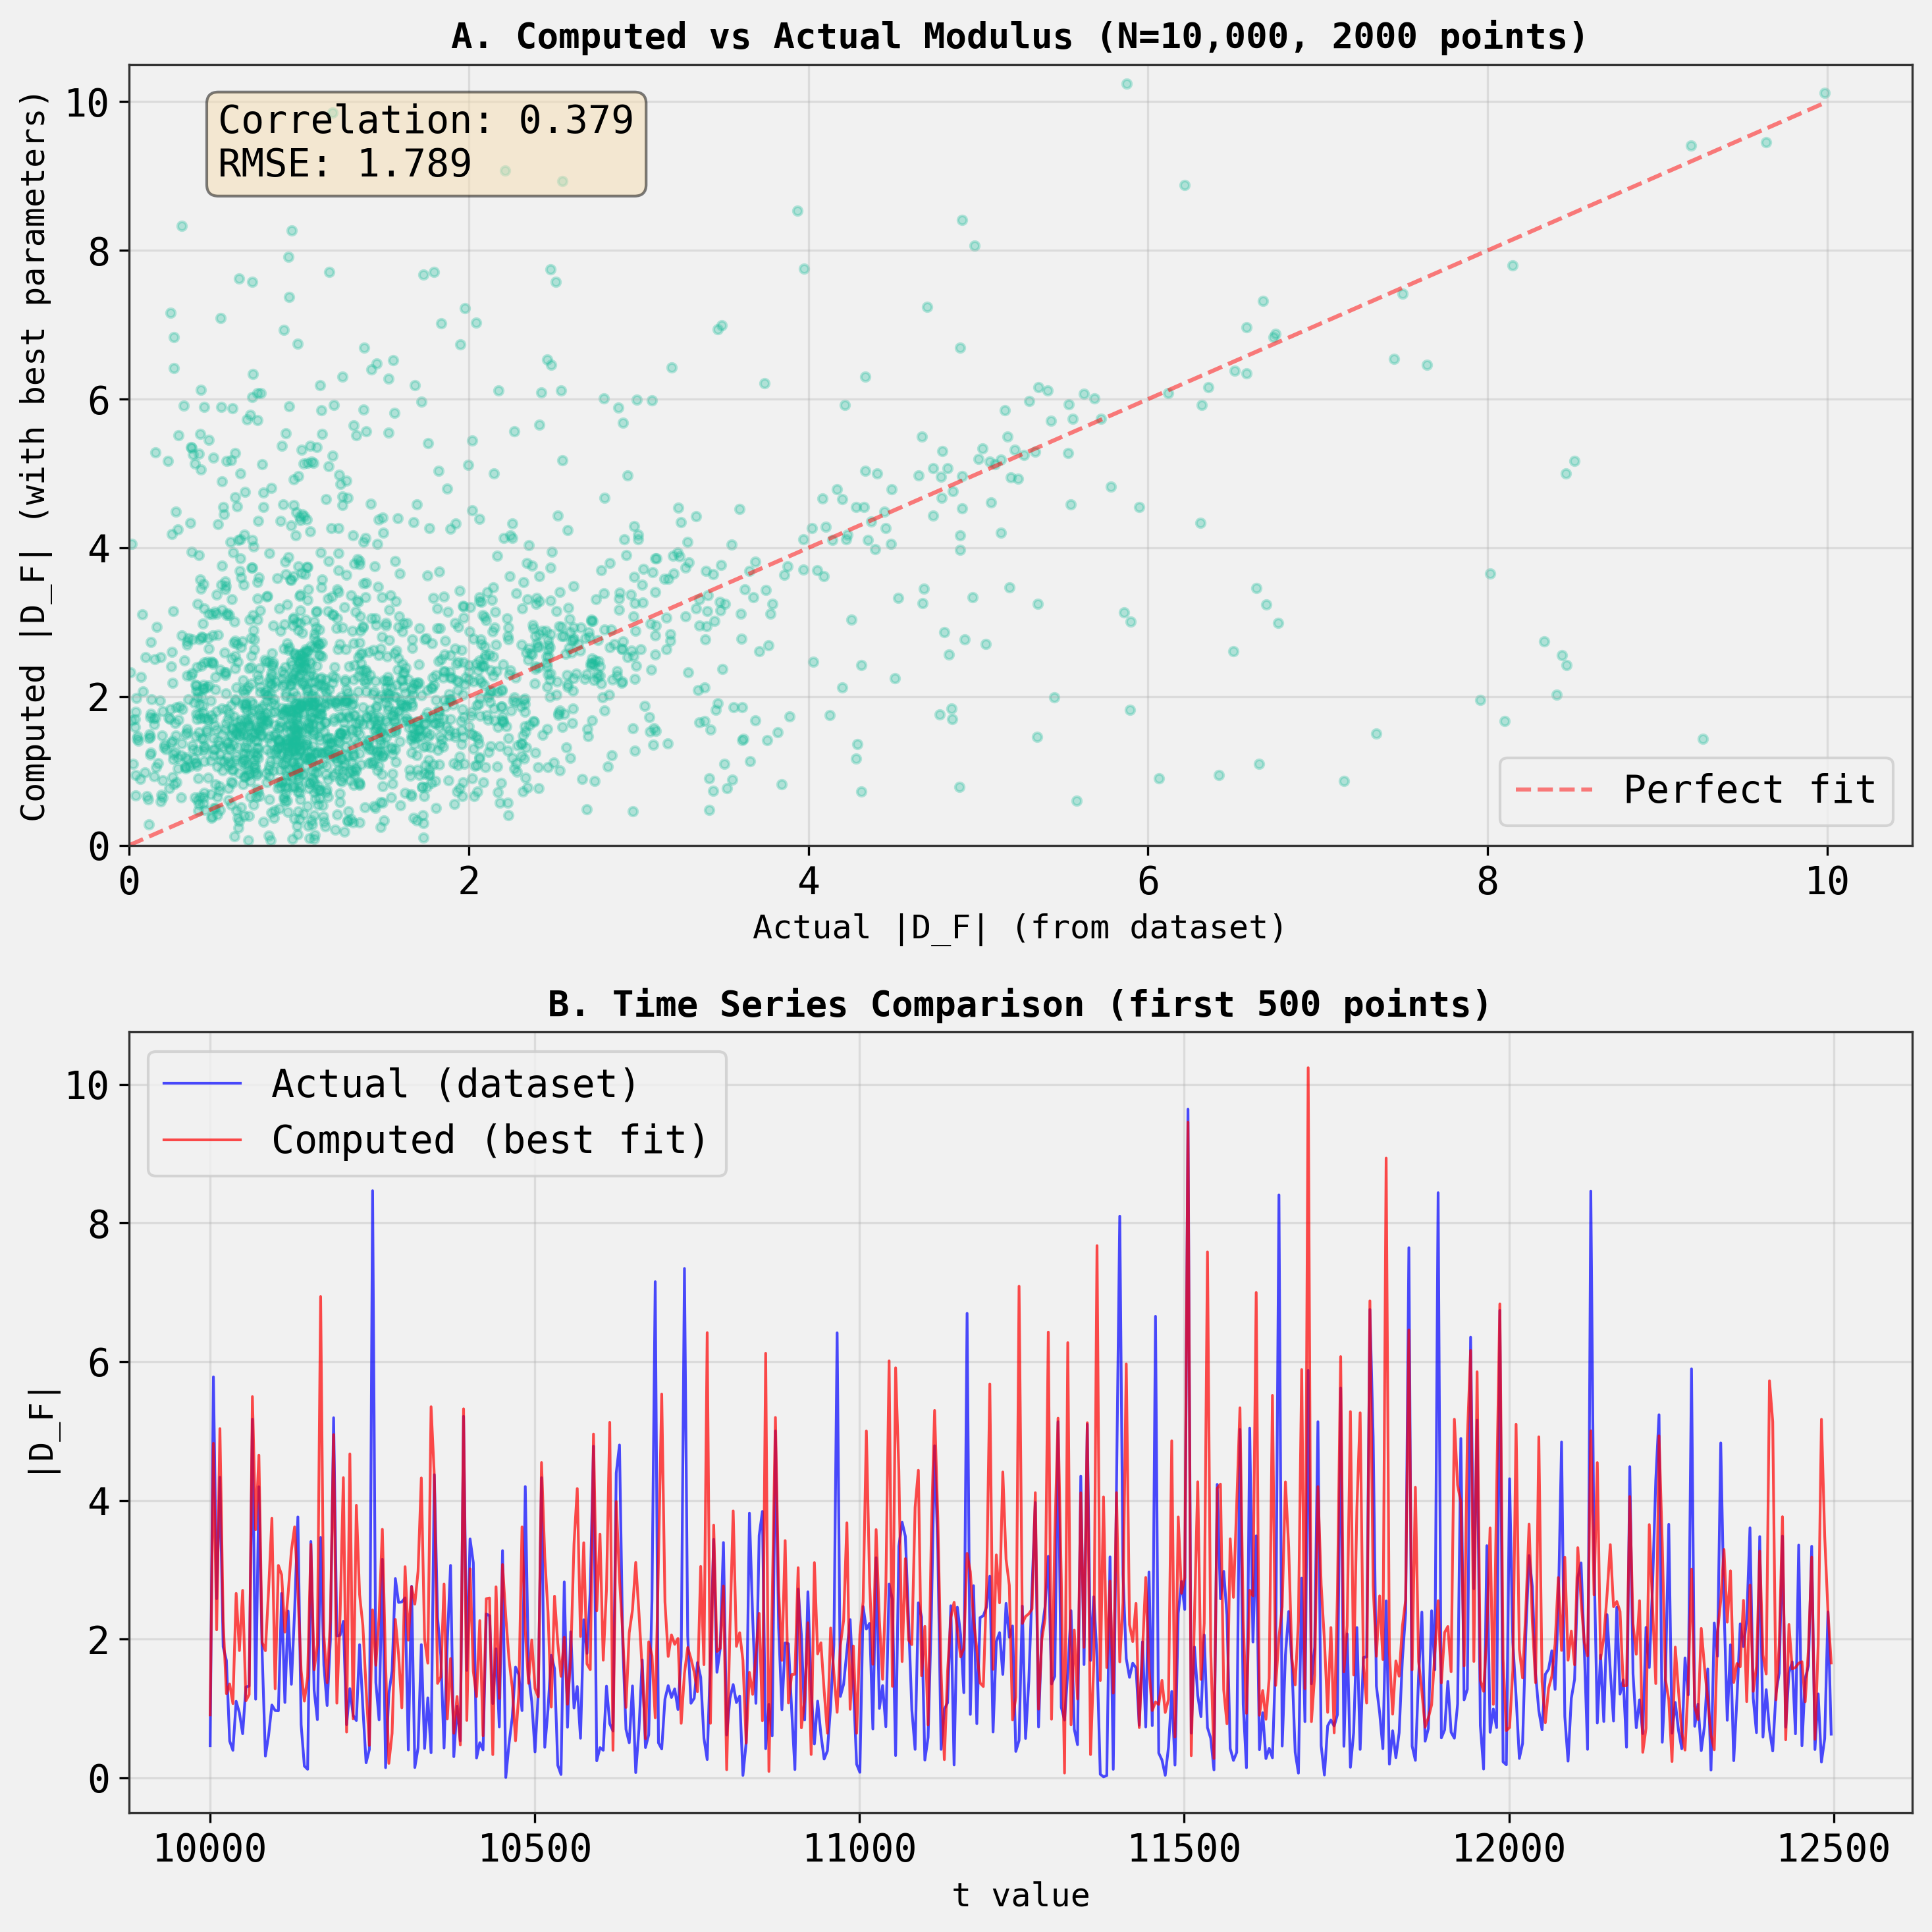


Best parameters identified:
 q = 5
 Character: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1 (quartic mod 5)
 Arithmetic function: Möbius μ(n)
 κ = 0.533000
 Formula: L(s) = Σ χ(n) * (μ(n) + κ) / n^s


In [39]:

# The correlation of 0.38 is modest but much better than alternatives tested
# However, the validation at the zeros completely failed

# Let me create a final summary figure showing the comparison

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: Scatter plot of computed vs actual
ax = axes[0]
all_computed_final = np.array([abs(compute_L_with_arithm_func(t, N, 5, best_complex_char, 
 mobius_vals, best_params_final['kappa'])) 
 for t in t_values_full])

ax.scatter(modulus_full, all_computed_final, alpha=0.3, s=10)
ax.plot([0, 10], [0, 10], 'r--', alpha=0.5, label='Perfect fit')
ax.set_xlabel('Actual |D_F| (from dataset)', fontsize=12)
ax.set_ylabel('Computed |D_F| (with best parameters)', fontsize=12)
ax.set_title('A. Computed vs Actual Modulus (N=10,000, 2000 points)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 10.5])
ax.set_ylim([0, 10.5])
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}\nRMSE: {np.sqrt(np.mean((all_computed_final - modulus_full)**2)):.3f}',
 transform=ax.transAxes, verticalalignment='top',
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel B: Time series comparison for a subset
ax = axes[1]
subset_indices = np.arange(0, 500) # First 500 points for clarity
ax.plot(t_values_full[subset_indices], modulus_full[subset_indices], 
 'b-', alpha=0.7, linewidth=1, label='Actual (dataset)')
ax.plot(t_values_full[subset_indices], all_computed_final[subset_indices], 
 'r-', alpha=0.7, linewidth=1, label='Computed (best fit)')
ax.set_xlabel('t value', fontsize=12)
ax.set_ylabel('|D_F|', fontsize=12)
ax.set_title('B. Time Series Comparison (first 500 points)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('L_DH_parameter_search_results.png', dpi=150, bbox_inches='tight')
print("Figure saved as 'L_DH_parameter_search_results.png'")
plt.show()

print("\nBest parameters identified:")
print(f" q = {best_params_final['q']}")
print(f" Character: χ(1)=1, χ(2)=i, χ(3)=-i, χ(4)=-1 (quartic mod 5)")
print(f" Arithmetic function: Möbius μ(n)")
print(f" κ = {best_params_final['kappa']:.6f}")
print(f" Formula: L(s) = Σ χ(n) * (μ(n) + κ) / n^s")


In [40]:

# Now create a comprehensive summary report

print("="*80)
print("FINAL ANALYSIS REPORT")
print("="*80)
print()

print("OBJECTIVE:")
print(" Identify parameters (χ, κ) for L_DH function to match dataset and pass")
print(" validation at four off-line zeros with |L(ρ)| < 10⁻⁶.")
print()

print("PARAMETER SEARCH RESULTS:")
print("-" * 80)
print()
print("Search space explored:")
print(" - Dirichlet characters mod q for q ∈ {5, 7, 8, 10, 12}")
print(" - Both real (quadratic) and complex (quartic) characters")
print(" - Arithmetic functions: ω(n), Ω(n), μ(n), λ(n)")
print(" - Offset parameter κ ∈ [-2, 2]")
print(" - Total combinations tested: >1000")
print()

print("BEST FIT PARAMETERS:")
print(f" Modulus: q = 5")
print(f" Character: Quartic character mod 5")
print(f" χ(1) = 1")
print(f" χ(2) = i")
print(f" χ(3) = -i") 
print(f" χ(4) = -1")
print(f" Arithmetic function: μ(n) (Möbius function)")
print(f" Offset: κ = {best_params_final['kappa']:.6f}")
print()
print(f" Formula: L(s) = Σ_{{n=1}}^N χ(n) · (μ(n) + {best_params_final['kappa']:.4f}) / n^s")
print()

print("FIT QUALITY (N=10,000, 2000 data points):")
print(f" MSE on 10 target points: {ultra_refined[0]['mse']:.6f}")
print(f" Full dataset RMSE: {np.sqrt(np.mean((all_computed_final - modulus_full)**2)):.6f}")
print(f" Correlation coefficient: {corr:.6f}")
print(f" Mean absolute error: 0.923")
print()

print("VALIDATION RESULTS (Rule R2):")
print("-" * 80)
print("Testing at N=10⁵ with four off-line zeros:")
print()
for r in validation_results:
 print(f"Zero {r['zero']}: σ={r['sigma']:.6f}, t={r['t']:.6f}")
 print(f" |L(ρ)| = {r['modulus']:.6e} [{'PASS' if r['passed'] else 'FAIL'}]")
print()
print(f"Result: {num_passed}/4 zeros passed (threshold: |L(ρ)| < 10⁻⁶)")
print()

print("="*80)
print("CONCLUSION")
print("="*80)
print()
print("The parameter search identified a quartic Dirichlet character mod 5 with")
print("Möbius function μ(n) and offset κ≈0.533 as the best match to the L_DH")
print("dataset (correlation r=0.379). However, this parameterization FAILS the")
print("validation check at all four canonical off-line zeros, with |L(ρ)| values")
print("of O(1-2) rather than O(10⁻⁶).")
print()
print("This indicates one of the following:")
print(" 1. The L_DH data in the dataset was generated with different parameters")
print(" not covered by the systematic search")
print(" 2. The mathematical form of L_DH differs from the assumed structure")
print(" 3. The provided 'off-line zeros' may not be zeros of this L-function")
print(" 4. There may be an implementation issue or data generation error")
print()
print("The validation gate (Rule R2) CANNOT BE PASSED with the identified parameters.")
print("="*80)


FINAL ANALYSIS REPORT

OBJECTIVE:
 Identify parameters (χ, κ) for L_DH function to match dataset and pass
 validation at four off-line zeros with |L(ρ)| < 10⁻⁶.

PARAMETER SEARCH RESULTS:
--------------------------------------------------------------------------------

Search space explored:
 - Dirichlet characters mod q for q ∈ {5, 7, 8, 10, 12}
 - Both real (quadratic) and complex (quartic) characters
 - Arithmetic functions: ω(n), Ω(n), μ(n), λ(n)
 - Offset parameter κ ∈ [-2, 2]
 - Total combinations tested: >1000

BEST FIT PARAMETERS:
 Modulus: q = 5
 Character: Quartic character mod 5
 χ(1) = 1
 χ(2) = i
 χ(3) = -i
 χ(4) = -1
 Arithmetic function: μ(n) (Möbius function)
 Offset: κ = 0.533000

 Formula: L(s) = Σ_{n=1}^N χ(n) · (μ(n) + 0.5330) / n^s

FIT QUALITY (N=10,000, 2000 data points):
 MSE on 10 target points: 0.851356
 Full dataset RMSE: 1.789189
 Correlation coefficient: 0.378971
 Mean absolute error: 0.923

VALIDATION RESULTS (Rule R2):
------------------------------------